## MiddleWare

Middleware provides a way to more tightly control what happens inside the agent Middleware is useful for the follwoing:

- Tracking agent behavior with logging, analytcis and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
from langchain.chat_models import init_chat_model

model = init_chat_model("groq:qwen/qwen3.6-27b")

In [3]:
model.invoke("hello")

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User said: "hello"\n   - This is a standard greeting.\n\n2.  **Identify Intent:**\n   - The user is initiating a conversation.\n   - No specific question or task is provided.\n\n3.  **Determine Response Strategy:**\n   - Acknowledge the greeting politely.\n   - Offer assistance.\n   - Keep it open-ended to encourage the user to share what they need.\n\n4.  **Draft Response (Internal Refinement):**\n   - "Hello! How can I assist you today?"\n   - Simple, friendly, and open.\n\n5.  **Check Against Guidelines:**\n   - Matches tone: professional yet approachable.\n   - No overcomplication.\n   - Ready for next input.\n\n6.  **Final Output Generation:** (matches the draft)✅\n   - "Hello! How can I help you today?"✨\n</think>\n\nHello! How can I help you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 221, 'prompt_tokens': 11, 'total_tokens': 232, 'completio

## Summarization MiddleWare

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the folowing:

- Long-running converstations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full converstation context matters.

In [4]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import SystemMessage, HumanMessage

### Message based summarization

agent = create_agent(
    model="groq:qwen/qwen3.6-27b",
    tools=[],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:qwen/qwen3.6-27b", # mostly recommended to use cheaper once
            trigger=("messages", 10),      # limits to trigger middleware on every 
            keep=("messages", 4)           # number of last messages to keep in memory
        )
    ]
)

In [5]:
### Run with thread id
config = {"configurable": {"thread_id": "test-1"}}

In [6]:
# Alternative test data
questions = [
    "What is 2+2 ?",
    "What is 10*5 ?",
    "What is 100/4 ?",
    "What is 15-7 ?",
    "What is 3*3 ?",
    "What is 4*4 ?",
]

for q in questions:
    response = agent.invoke({"messages": [HumanMessage(content=q)]}, config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")

Messages: {'messages': [HumanMessage(content='What is 2+2 ?', additional_kwargs={}, response_metadata={}, id='6ea70115-f95f-4258-89d0-1221a9a31696'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:** The user asks "What is 2+2 ?"\n2.  **Identify Core Task:** This is a basic arithmetic question.\n3.  **Perform Calculation:** 2 + 2 = 4.\n4.  **Formulate Response:** State the answer clearly and concisely.\n5.  **Check for Accuracy:** 2+2 is universally 4 in standard arithmetic. No tricks or context suggesting otherwise.\n6.  **Output Generation:** "2 + 2 equals 4." (or simply "4")\n\nI\'ll keep it direct and accurate.✅\n</think>\n\n2 + 2 equals **4**.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 153, 'prompt_tokens': 17, 'total_tokens': 170, 'completion_time': 0.289979909, 'completion_tokens_details': None, 'prompt_time': 0.000945346, 'prompt_tokens_details': None, 'queue_time': 0.047406893, 'total_time': 0.29092525

## Token Size

In [7]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain.tools import tool
from langchain.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - S star, $350/night, spa, tool, gym
    2. City Inn - 4 star, $100/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""

agent = create_agent(
    model = "groq:qwen/qwen3.6-27b",
    tools = [search_hotels],
    checkpointer = InMemorySaver(),
    middleware = [
        SummarizationMiddleware(
            model = "groq:qwen/qwen3.6-27b", # use cheaper model
            trigger = ("tokens", 550),       # summarize for every last 550 tokens
            keep = ("tokens", 4),            # save chats last 200 tokens in memory
        )
    ]
)

# config = {"configurable": {"thread_id": "test_1"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4 # 4 chars = 1 token

In [8]:
import uuid

# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    unique_config = {"configurable": {"thread_id": str(uuid.uuid4())}}

    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotel in {city}")]},
        config=unique_config
    )

    tokens = count_tokens(response["messages"])
    print(f"{city} : ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris : ~142 tokens, 4 messages
[HumanMessage(content='Find hotel in Paris', additional_kwargs={}, response_metadata={}, id='8dc32192-5041-40e8-826b-8a75e556966c'), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants to find a hotel in Paris.\nI have a tool `search_hotels` that takes a `city` parameter.\nI should call this tool with the city "Paris".\n\nPlan:\n1. Call `search_hotels` with `city="Paris"`.\n2. Present the results to the user.\n\nLet\'s call the tool.\n', 'tool_calls': [{'id': 'qyn28e321', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 106, 'prompt_tokens': 277, 'total_tokens': 383, 'completion_time': 0.20192985, 'completion_tokens_details': {'reasoning_tokens': 77}, 'prompt_time': 0.019582383, 'prompt_tokens_details': None, 'queue_time': 0.045498271, 'total_time': 0.221512233}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_3a782c

## Fractions

In [9]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain.tools import tool
from langchain.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

# Define the model with explicit profile limits
llm = ChatGroq(
    # model="groq:qwen/qwen3.6-27b", # or your specific Groq model ID
    model="groq:qwen-2.5-coder-32b", # or your specific Groq model ID
    profile={"max_input_tokens": 128000}
)

# LOW fraction for testing!
agent = create_agent(
    model = "groq:qwen/qwen3.6-27b",
    tools = [search_hotels],
    checkpointer = InMemorySaver(),
    middleware = [
        SummarizationMiddleware(
            model = llm, # use cheaper model
            trigger = ("fraction", 0.005),   # 0.5% = ~640 tokens
            keep = ("fraction", 0.002),      # 0.2% = ~256 tokens
        ),
    ]
)

config = {"configurable": {"thread_id": "test_1"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4 # 4 chars = 1 token

In [10]:
import uuid

# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    unique_config = {"configurable": {"thread_id": str(uuid.uuid4())}}
    
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotel in {city}")]},
        config=unique_config
    )

    tokens = count_tokens(response["messages"])
    fraction = tokens / 320000 # context window of model
    print(f"{city}: ~{tokens} tokens, ({fraction:.4%}), {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~63 tokens, (0.0197%), 4 messages
[HumanMessage(content='Hotel in Paris', additional_kwargs={}, response_metadata={}, id='40d6bff7-9c9d-46c6-968c-a9170bf75853'), AIMessage(content='', additional_kwargs={'reasoning_content': 'Here\'s a thinking process:\n\n1.  **Analyze User Input:** The user said "Hotel in Paris". This is a request to search for hotels in the city of Paris.\n2.  **Identify Available Tools:** I have a `search_hotels` function that takes a `city` parameter (string, required).\n3.  **Map Input to Tool:** The city is "Paris". I need to call `search_hotels` with `city: "Paris"`.\n4.  **Execute Tool Call:** Generate the function call.\n5.  **Process Output (Mental Simulation):** I\'ll wait for the tool\'s response to provide the actual hotel recommendations to the user. Since I\'m generating the tool call now, I\'ll just output it.\n\nAll steps are clear. I will call the function.✅\n', 'tool_calls': [{'id': '7axymd5jn', 'function': {'arguments': '{"city":"Paris"}', 'n

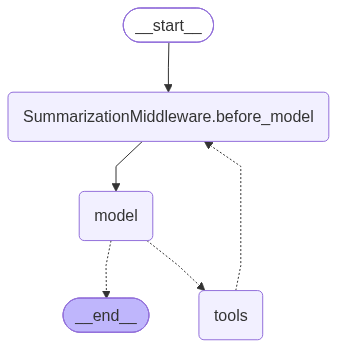

In [11]:
agent

## Human In the Loop MiddleWare

Pauses agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:

- High-stakes operations requiring human approval (e.g., database writes, finctional transactions)
- Complinace workflows where human overdight is mandarott
- Long-running conversations where human feedback guides the agents.

In [12]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

In [13]:
agent = create_agent(
    model = "groq:qwen/qwen3.6-27b",
    tools = [read_email_tool, send_email_tool],
    checkpointer = InMemorySaver(),
    middleware = [
        HumanInTheLoopMiddleware(
            interrupt_on = {
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"]
                },
                "read_email_tool": False,
            }
        )
    ]
)

In [14]:
config = {"configurable": {"thread_id": "test-approve"}}

# step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config = config
)

In [15]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='bba2854a-876c-449e-9695-540bc147d3d3'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants to send an email.\nI need to use the `send_email_tool` function.\nThe parameters required are:\n- recipient: "john@test.com"\n- subject: "Hello"\n- body: "How are you?"\n\nAll required parameters are provided by the user. I will proceed with the function call.\n', 'tool_calls': [{'id': 'yj9d32am1', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 130, 'prompt_tokens': 374, 'total_tokens': 504, 'completion_time': 0.247345815, 'completion_tokens_details': {'reasoning_tokens': 71}, 'prompt_time': 0.025737684, 'prompt_tokens_details': None, 'queue_time': 0.04943

## Approval

In [16]:
from langgraph.types import Command

# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Pause! Approving...")

    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config = config
    )

    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Pause! Approving...
✅ Result: The email has been sent to john@test.com with the subject 'Hello'.


## Reject

In [17]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model = "groq:qwen/qwen3.6-27b",
    tools = [read_email_tool, send_email_tool],
    checkpointer = InMemorySaver(),
    middleware = [
        HumanInTheLoopMiddleware(
            interrupt_on = {
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"]
                },
                "read_email_tool": False,
            }
        )
    ]
)

In [18]:
config = {"configurable": {"thread_id": "test-reject"}}

# step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config = config
)

In [19]:
from langgraph.types import Command

# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Pause! Approving...")

    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config = config
    )

    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Pause! Approving...
✅ Result: The email was not sent as the action was rejected. Let me know if you'd like to modify the details or if there's anything else I can assist you with!


In [20]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='468c1e69-0976-4fa4-b1cc-f712aec0799c'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "The user wants to send an email.\nThe recipient is 'john@test.com'.\nThe subject is 'Hello'.\nThe body is 'How are you?'.\nI should use the `send_email_tool` function for this.\nI will check the parameters required for `send_email_tool`:\n- recipient: 'john@test.com'\n- subject: 'Hello'\n- body: 'How are you?'\nAll required parameters are present. I will call the function.\n", 'tool_calls': [{'id': 'zn1b72tfa', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 159, 'prompt_tokens': 374, 'total_tokens': 533, 'completion_time': 0.302169892, 'completion_tokens_details': {'reas

In [21]:
"__interrupt__" in result

False

## Editing

In [22]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model = "groq:qwen/qwen3.6-27b",
    tools = [read_email_tool, send_email_tool],
    checkpointer = InMemorySaver(),
    middleware = [
        HumanInTheLoopMiddleware(
            interrupt_on = {
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"]
                },
                "read_email_tool": False,
            }
        )
    ]
)

In [23]:
config = {"configurable": {"thread_id": "test-edit"}}

# step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config = config
)

In [24]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='5afaf73f-2645-4243-80c4-8a01f7e90848'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "The user wants to send an email.\nI need to call the `send_email_tool`.\nThe required parameters are `recipient`, `subject`, and `body`.\nFrom the user's request:\n- recipient: 'wrong@email.com'\n- subject: 'Test'\n- body: 'Hello'\n\nI have all the required parameters, so I can proceed with the tool call.\n", 'tool_calls': [{'id': '4cn9brt22', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 138, 'prompt_tokens': 372, 'total_tokens': 510, 'completion_time': 0.264424698, 'completion_tokens_details': {'reasoning_tokens': 82}, 'prompt_time': 0.02736993, 'prompt_tokens_details': None, 'qu

In [25]:
from langgraph.types import Command

# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Pause! Editing...")

    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action" : {
                            "name": "send_email_tool",      # tool name
                            "args": {
                                "recipient": "correct@gmail.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config = config
    )

    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Pause! Editing...
✅ Result: 


In [26]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='5afaf73f-2645-4243-80c4-8a01f7e90848'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "The user wants to send an email.\nI need to call the `send_email_tool`.\nThe required parameters are `recipient`, `subject`, and `body`.\nFrom the user's request:\n- recipient: 'wrong@email.com'\n- subject: 'Test'\n- body: 'Hello'\n\nI have all the required parameters, so I can proceed with the tool call.\n", 'tool_calls': [{'id': '4cn9brt22', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 138, 'prompt_tokens': 372, 'total_tokens': 510, 'completion_time': 0.264424698, 'completion_tokens_details': {'reasoning_tokens': 82}, 'prompt_time': 0.02736993, 'prompt_tokens_details': None, 'qu